In [1]:
import os
import pandas as pd
import cv2
import numpy as np
from matplotlib import pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet50, EfficientNetB0, InceptionV3, DenseNet121, Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf 
from script import process_df_for_resnet, plot_image_with_predictions, create_model, get_top_predictions

big_csv_path = "2_preprocessed_sequences_with_interpolation_v0.csv"
df_big = pd.read_csv(big_csv_path)
df_big.columns

csv_path = "test_example.csv"
df = pd.read_csv(csv_path)

df["Image_basename"] = [os.path.basename(path) for path in df.img_rel_path]

df_bbox = df_big.copy()
df_bbox = df_bbox[['Image_basename', 'yolo_bbox_xcenter', 'yolo_bbox_ycenter','yolo_bbox_width', 'yolo_bbox_height', 'nb_detections']]

final_df = pd.merge(df, df_bbox, on='Image_basename', how='inner')



In [2]:
X, y, category_mapping = process_df_for_resnet(final_df, min_num=1, label_cat="arbre")

In [3]:
label_category= "arbre"

In [4]:
model_name = "inceptionv3"
print("Creating model ...")
model = create_model(backbone_name=model_name, num_classes=1)

model.load_weights("test_inceptionv3_arbre_equilibrate.weights.h5")

Creating model ...


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


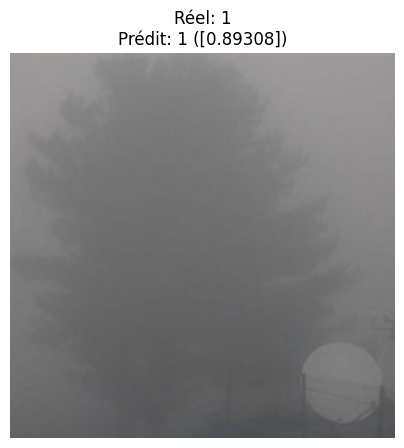

In [5]:
predictions = model.predict(np.array(X))

y_predict_binary =np.array( [1 if x>0.5 else 0 for x in predictions])
count = 0

for i, image in enumerate(X):
    if count>10:
        break
    count+=1
    if y[i] == 0:
        continue
    true_label = y[i]
    predicted_label = y_predict_binary[i]
    confidence = predictions[i]
    plot_image_with_predictions(image, true_label, predicted_label, confidence)

Creating model ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 998ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 970ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 962ms/step
brume
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 984ms/step


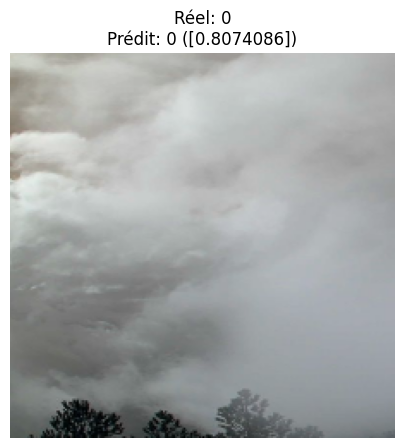

{'brume': np.float32(0.80740863), 'batiment': np.float32(0.143728), 'arbre': np.float32(0.025233988)}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
glare
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 991ms/step


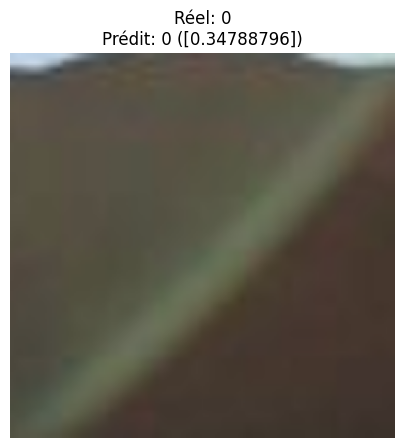

{'glare': np.float32(0.34788796), 'brume': np.float32(0.2937881), 'batiment': np.float32(0.123948954)}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
brume
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


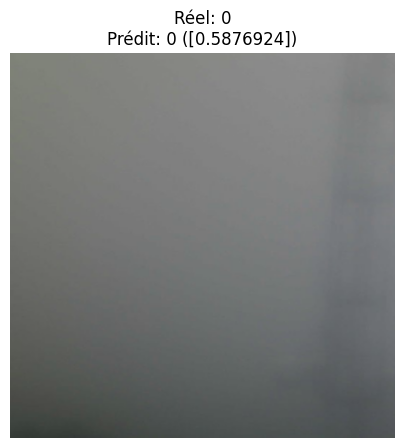

{'brume': np.float32(0.5876923), 'glare': np.float32(0.34764507), 'batiment': np.float32(0.13921466)}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
arbre
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


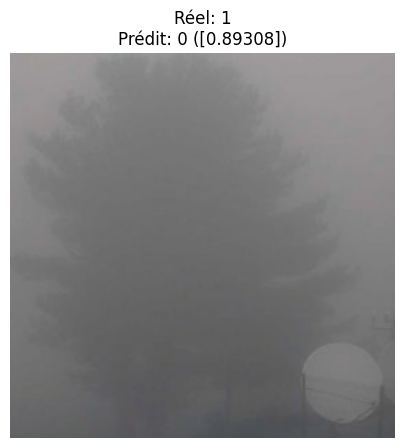

{'arbre': np.float32(0.8930801), 'brume': np.float32(0.58368546), 'glare': np.float32(0.347647)}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
brume
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


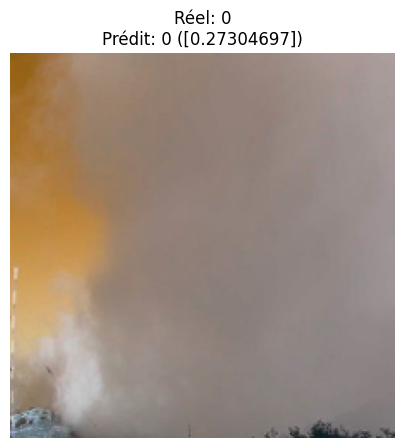

{'brume': np.float32(0.27304694), 'batiment': np.float32(0.11405323), 'arbre': np.float32(0.05550854)}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
glare
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


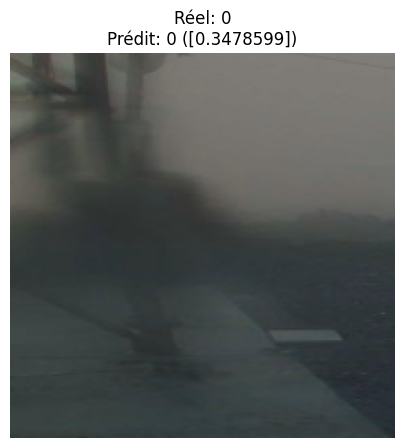

{'glare': np.float32(0.34785983), 'brume': np.float32(0.23518564), 'batiment': np.float32(0.15140958)}


In [11]:
model_name = "inceptionv3"
print("Creating model ...")
models = {
    "arbre" : create_model(backbone_name=model_name, num_classes=1),
    "brume" : create_model(backbone_name=model_name, num_classes=1),
    "batiment" : create_model(backbone_name=model_name, num_classes=1),
    "glare" : create_model(backbone_name=model_name, num_classes=1),
}
models["arbre"].load_weights("test_inceptionv3_arbre_equilibrate.weights.h5")
models["brume"].load_weights("test_inceptionv3_brume_equilibrate.weights.h5")
models["batiment"].load_weights("test_inceptionv3_batiment_equilibrate.weights.h5")
models["glare"].load_weights("test_inceptionv3_glare_equilibrate.weights.h5")
for i, image in enumerate(X):
    top_predictions = get_top_predictions(models, image, top_n=3)
    print(next(iter(top_predictions)))
    prediction = models[next(iter(top_predictions))].predict(np.array(X))[i]
    predicted_label =np.array( [1 if x>0.5 else 0 for x in predictions])[0]
    plot_image_with_predictions(image, y[i], predicted_label, prediction)
    print(top_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


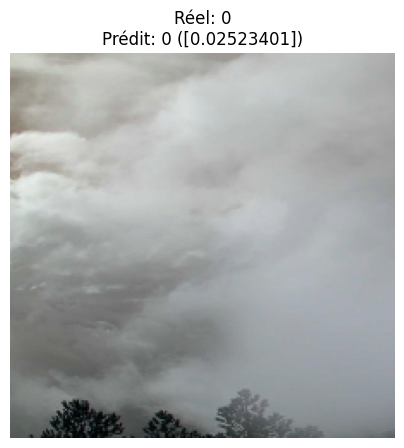

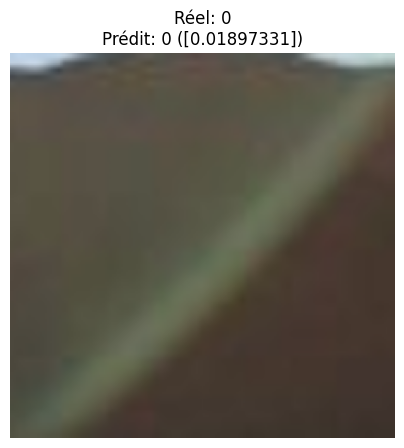

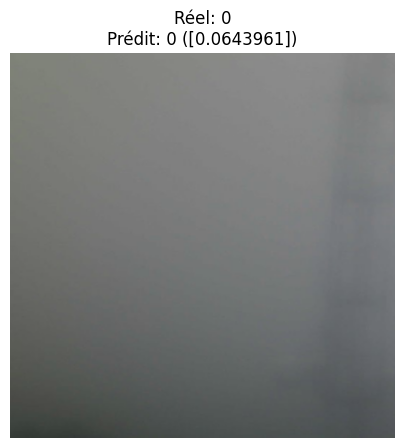

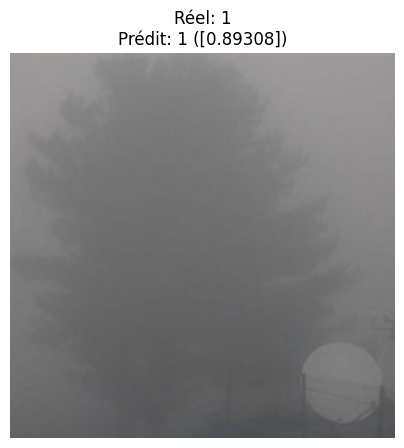

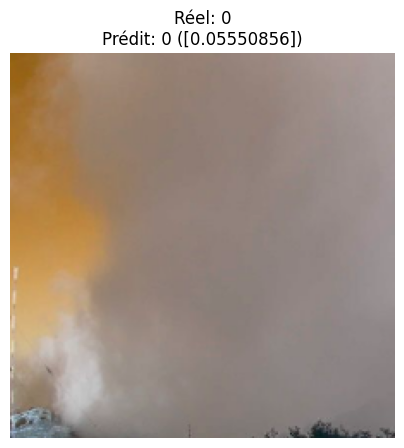

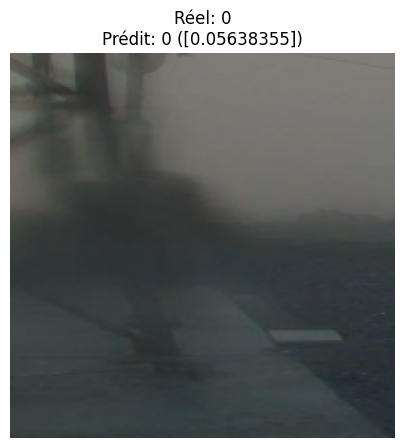

In [7]:
top_predictions = get_top_predictions(models, image, top_n=3)
print(top_predictions)